In [ ]:
#IMPORTANT!! DO NOT RUN ALL CELLS, RUN ONE AT A TIME!!!!!!!!

# import libraries
import os
import json
import time
import math
from dataclasses import dataclass
from typing import Dict, List, Tuple
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torchvision
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

In [ ]:
# Path to your dataset root (folder that contains class subfolders)
DATASET_DIR = r"./Images_Other_Foods/images"

# This will create:
#   SPLIT_DIR/train/<class>/*
#   SPLIT_DIR/val/<class>/*
#   SPLIT_DIR/test/<class>/*
SPLIT_DIR  = r"./Images_Other_Foods/images/SplitDataset/"

OUTPUT_DIR  = r"./food_model_out"   # where weights + metadata will be saved
NUTRITION_CSV = r"./nutrition.csv"  # optional (for your app); not used by training code below

# Split ratios (must sum to 1.0)
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10

# Create output directories if they don't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SPLIT_DIR, exist_ok=True)

# Set device for training
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# Hyperparameters for model training
BATCH_SIZE = 32
NUM_EPOCHS = 2
LR = 3e-4
IMG_SIZE = 224
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


Device: cpu


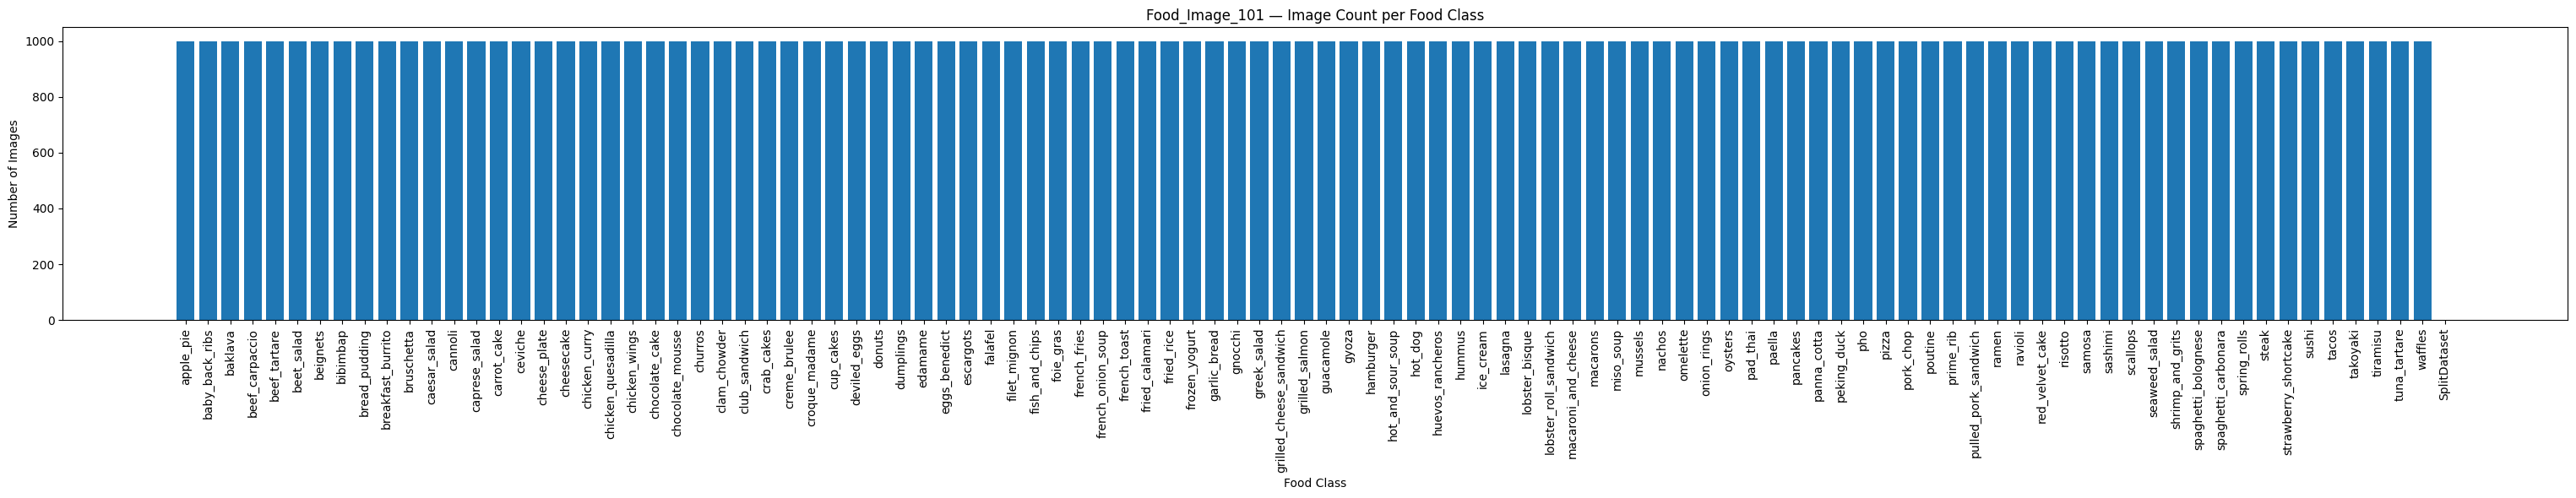

Total classes: 102
Total images: 101000
Min images in a class: 0
Max images in a class: 1000
Mean images per class: 990.2


In [ ]:
import os
import matplotlib.pyplot as plt
from collections import Counter

# Count images per class (folder)
class_counts = {}

# Loop through each class folder in the dataset directory
for class_name in sorted(os.listdir(DATASET_DIR)):
    class_path = os.path.join(DATASET_DIR, class_name)
    if os.path.isdir(class_path):
        num_images = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        ])
        class_counts[class_name] = num_images

# Sort by count (descending)
class_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

# Split into labels and values
labels = list(class_counts.keys())
values = list(class_counts.values())

# Plot
plt.figure(figsize=(max(12, len(labels) * 0.3), 6))
plt.bar(labels, values)
plt.xticks(rotation=90)
plt.ylabel("Number of Images")
plt.xlabel("Food Class")
plt.title("Food_Image_101 — Image Count per Food Class")
plt.tight_layout()
plt.show()

# Optional: quick stats
print(f"Total classes: {len(labels)}")
print(f"Total images: {sum(values)}")
print(f"Min images in a class: {min(values)}")
print(f"Max images in a class: {max(values)}")
print(f"Mean images per class: {sum(values)/len(values):.1f}")


In [ ]:
import os, random, shutil
from pathlib import Path

# Function to split dataset into train/val/test folders while preserving class subfolders. It takes source and destination paths, split ratios, random seed, and whether to copy or move files. It shuffles images, calculates split sizes, creates necessary directories, and places files accordingly.
def split_class_folders_train_val_test(
    src_root: str,
    dst_root: str,
    train_ratio: float = 0.8,
    val_ratio: float = 0.1,
    test_ratio: float = 0.1,
    seed: int = 42,
    copy: bool = True,
):
    """
    Creates a standard ML directory split by COPYING (or moving) images:

        dst_root/train/<class>/*
        dst_root/val/<class>/*
        dst_root/test/<class>/*

    Assumes src_root has ImageFolder layout:
        src_root/<class>/*.jpg|png|...

    NOTE: This is completely doable with CNNs.
          The *split* is about evaluation hygiene, not model type.
    """

    # Validate ratios sum to 1.0
    assert abs((train_ratio + val_ratio + test_ratio) - 1.0) < 1e-6, "Ratios must sum to 1.0"
    random.seed(seed)

    # Convert to Path objects for easier manipulation
    src_root = Path(src_root)
    dst_root = Path(dst_root)

    # Create train/val/test directories
    for split in ["train", "val", "test"]:
        (dst_root / split).mkdir(parents=True, exist_ok=True)

    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    # Iterate over each class directory in the source root
    for class_dir in [p for p in src_root.iterdir() if p.is_dir()]:
        images = [p for p in class_dir.iterdir() if p.is_file() and p.suffix.lower() in exts]
        if not images:
            continue

        random.shuffle(images)

        n = len(images)
        n_train = int(n * train_ratio)
        n_val   = int(n * val_ratio)
        # remainder goes to test to guarantee all files are used
        n_test  = n - n_train - n_val

        train_imgs = images[:n_train]
        val_imgs   = images[n_train:n_train + n_val]
        test_imgs  = images[n_train + n_val:]

        # Create class dirs
        for split in ["train", "val", "test"]:
            (dst_root / split / class_dir.name).mkdir(parents=True, exist_ok=True)

        def place(files, split):
            for f in files:
                dst = dst_root / split / class_dir.name / f.name
                if dst.exists():
                    continue
                if copy:
                    shutil.copy2(f, dst)
                else:
                    shutil.move(str(f), str(dst))

        # place files in their respective folders
        place(train_imgs, "train")
        place(val_imgs, "val")
        place(test_imgs, "test")

    print("Split complete at:", dst_root)


In [5]:
# Call the split function to create train/val/test directories
split_class_folders_train_val_test(
    src_root=DATASET_DIR,
    dst_root=SPLIT_DIR,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    seed=SEED
)

Split complete at: Images_Other_Foods\images\SplitDataset


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os, json
from pathlib import Path

# Verify that split folders exist
SPLIT_DIR_PATH = Path(SPLIT_DIR)
TRAIN_DIR = SPLIT_DIR_PATH / "train"
VAL_DIR   = SPLIT_DIR_PATH / "val"
TEST_DIR  = SPLIT_DIR_PATH / "test"

# Quick sanity check to ensure splits were created
for p in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not p.exists():
        raise FileNotFoundError(f"Missing split folder: {p}. Did you run the split cell above?")

# Transforms (distribution-shift friendly)
#   Train: strong, realistic augments
#   Val/Test: clean + deterministic
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0), ratio=(0.75, 1.33)),
    transforms.RandomRotation(15),
    transforms.RandomPerspective(distortion_scale=0.4, p=0.30),
    transforms.ColorJitter(brightness=0.30, contrast=0.30, saturation=0.30, hue=0.05),
    transforms.RandomAutocontrast(p=0.30),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Val/Test transforms: deterministic + clean (no augments, just resize + norm)
eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Create datasets
train_ds = datasets.ImageFolder(str(TRAIN_DIR), transform=train_tfms)
val_ds   = datasets.ImageFolder(str(VAL_DIR),   transform=eval_tfms)
test_ds  = datasets.ImageFolder(str(TEST_DIR),  transform=eval_tfms)

# Get class names and number of classes
class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", num_classes)

# Create dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Quick sanity check: print number of images in each split
print("Train images:", len(train_ds))
print("Val images:", len(val_ds))
print("Test images:", len(test_ds))

# Save mapping for your web app (model output index -> class name)
idx_to_class = {v: k for k, v in train_ds.class_to_idx.items()}
with open(os.path.join(OUTPUT_DIR, "idx_to_class.json"), "w") as f:
    json.dump(idx_to_class, f, indent=2)


Classes: 101
Train images: 80800
Val images: 10100
Test images: 10100


In [ ]:
# Stronger backbone: ResNet50 pretrained on ImageNet
# If you want even stronger, we can swap to ConvNeXt / EfficientNet later.
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Replace the classification head with your dataset's number of classes
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

# Move model to device (GPU if available)
model = model.to(DEVICE)
print("Model:", type(model).__name__)


Model: ResNet


In [ ]:
import torch.optim as optimizer
import torch.nn as nn
criterion = nn.CrossEntropyLoss()
optimizer = optimizer.AdamW(model.parameters(), lr=LR)

# Evaluation function to compute Top-1 and Top-3 accuracy on a given dataloader. It iterates through batches, computes predictions, and counts correct classifications for both metrics.
@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader) -> Dict[str, float]:
    model.eval()
    correct_top1 = 0
    correct_top3 = 0
    total = 0

    # Iterate through batches in the dataloader
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model(images)
        probs = torch.softmax(logits, dim=1)

        # Top-1
        pred1 = torch.argmax(probs, dim=1)
        correct_top1 += (pred1 == labels).sum().item()

        # Top-3
        top3 = torch.topk(probs, k=3, dim=1).indices
        correct_top3 += (top3 == labels.unsqueeze(1)).any(dim=1).sum().item()

        total += labels.size(0)

    # Avoid division by zero
    return {
        "top1_acc": correct_top1 / total,
        "top3_acc": correct_top3 / total,
    }

# Training loop for one epoch. It sets the model to training mode, iterates through batches, computes loss, backpropagates, and updates weights. It accumulates the running loss to return the average loss for the epoch.
def train_one_epoch(model: nn.Module, loader: DataLoader) -> float:
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)

    return running_loss / len(loader.dataset)

# Main training loop across epochs. For each epoch, it trains the model for one epoch, evaluates on the validation set, and records metrics and time taken. It also saves the best model based on Top-1 accuracy.
best_top1 = 0.0
history = []

# Loop over epochs
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader)
    metrics = evaluate(model, val_loader)
    dt = time.time() - t0

    row = {"epoch": epoch, "train_loss": train_loss, **metrics, "seconds": dt}
    history.append(row)
    print(row)

    # Save best model by Top-1 accuracy
    if metrics["top1_acc"] > best_top1:
        best_top1 = metrics["top1_acc"]
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "best_model.pt"))
        print("Saved new best model:", best_top1)

# Convert training history to DataFrame for easier analysis and visualization
hist_df = pd.DataFrame(history)
hist_df



Training:   0%|          | 0/2525 [00:00<?, ?it/s]C:\Users\coles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training:   0%|          | 0/2525 [00:00<?, ?it/s]C:\Users\coles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'epoch': 1, 'train_loss': 1.729984781128345, 'top1_acc': 0.6975247524752475, 'top3_acc': 0.853069306930693, 'seconds': 10659.33039021492}
Saved new best model: 0.6975247524752475


Training:   0%|          | 0/2525 [00:00<?, ?it/s]C:\Users\coles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'epoch': 1, 'train_loss': 1.729984781128345, 'top1_acc': 0.6975247524752475, 'top3_acc': 0.853069306930693, 'seconds': 10659.33039021492}
Saved new best model: 0.6975247524752475


{'epoch': 2, 'train_loss': 1.1438086197281827, 'top1_acc': 0.7353465346534653, 'top3_acc': 0.8805940594059406, 'seconds': 10595.327599525452}
Saved new best model: 0.7353465346534653


Training:   0%|          | 0/2525 [00:00<?, ?it/s]C:\Users\coles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'epoch': 1, 'train_loss': 1.729984781128345, 'top1_acc': 0.6975247524752475, 'top3_acc': 0.853069306930693, 'seconds': 10659.33039021492}
Saved new best model: 0.6975247524752475


{'epoch': 2, 'train_loss': 1.1438086197281827, 'top1_acc': 0.7353465346534653, 'top3_acc': 0.8805940594059406, 'seconds': 10595.327599525452}
Saved new best model: 0.7353465346534653


,epoch,train_loss,top1_acc,top3_acc,seconds
0,1,1.729985,0.697525,0.853069,10659.33039
1,2,1.143809,0.735347,0.880594,10595.32760


In [ ]:
# Function to get all predictions and true labels from a dataloader. It sets the model to evaluation mode, iterates through batches, computes predictions, and accumulates them in lists which are returned as numpy arrays.
@torch.no_grad()
def get_all_preds(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    for images, labels in tqdm(loader, desc="Predicting"):
        images = images.to(DEVICE)
        logits = model(images)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())
    return np.array(all_preds), np.array(all_labels)

# Generate classification reports for validation and test sets. For the validation set, it uses the current model (which may have been tuned during training). For the test set, it loads the best model weights saved during training to ensure an unbiased evaluation. It prints the classification report for each set using sklearn's classification_report function.
print("=== Validation set report (used for tuning/early stopping) ===")
val_preds, val_labels = get_all_preds(model, val_loader)
print(classification_report(val_labels, val_preds, target_names=class_names))

# For the test set, we want to load the best model weights saved during training to ensure an unbiased evaluation. This simulates the real-world scenario where you would deploy the best model and evaluate it on unseen data.
print("\n=== Test set report (final, untouched during training/tuning) ===")
# Load best weights before testing
best_path = os.path.join(OUTPUT_DIR, "best_model.pt")
if os.path.exists(best_path):
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    model = model.to(DEVICE)
else:
    print("Warning: best_model.pt not found; using current model weights.")

# Now get predictions and print classification report for the test set
test_preds, test_labels = get_all_preds(model, test_loader)
print(classification_report(test_labels, test_preds, target_names=class_names))


=== Validation set report (used for tuning/early stopping) ===


Predicting:   0%|          | 0/316 [00:00<?, ?it/s]C:\Users\coles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Predicting: 100%|██████████| 316/316 [18:46<00:00,  3.57s/it]


                         precision    recall  f1-score   support

              apple_pie       0.55      0.53      0.54       100
         baby_back_ribs       0.75      0.76      0.75       100
                baklava       0.88      0.77      0.82       100
         beef_carpaccio       0.76      0.83      0.79       100
           beef_tartare       0.74      0.78      0.76       100
             beet_salad       0.85      0.58      0.69       100
               beignets       0.94      0.67      0.78       100
               bibimbap       0.91      0.79      0.84       100
          bread_pudding       0.48      0.63      0.55       100
      breakfast_burrito       0.86      0.37      0.52       100
             bruschetta       0.47      0.76      0.58       100
           caesar_salad       0.70      0.89      0.78       100
                cannoli       0.64      0.82      0.72       100
          caprese_salad       0.65      0.84      0.73       100
            carrot_cake 

Predicting:   0%|          | 0/316 [00:00<?, ?it/s]C:\Users\coles\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Predicting: 100%|██████████| 316/316 [24:19<00:00,  4.62s/it]

                         precision    recall  f1-score   support

              apple_pie       0.62      0.61      0.61       100
         baby_back_ribs       0.80      0.78      0.79       100
                baklava       0.86      0.84      0.85       100
         beef_carpaccio       0.82      0.86      0.84       100
           beef_tartare       0.70      0.71      0.71       100
             beet_salad       0.74      0.52      0.61       100
               beignets       0.91      0.73      0.81       100
               bibimbap       0.95      0.89      0.92       100
          bread_pudding       0.56      0.70      0.62       100
      breakfast_burrito       0.92      0.33      0.49       100
             bruschetta       0.46      0.78      0.58       100
           caesar_salad       0.68      0.89      0.77       100
                cannoli       0.66      0.91      0.76       100
          caprese_salad       0.73      0.80      0.77       100
            carrot_cake 

Saved confusion matrix CSV to: ./food_model_out\confusion_matrix_test.csv
Saved confusion matrix PNG to: ./food_model_out\confusion_matrix_test.png


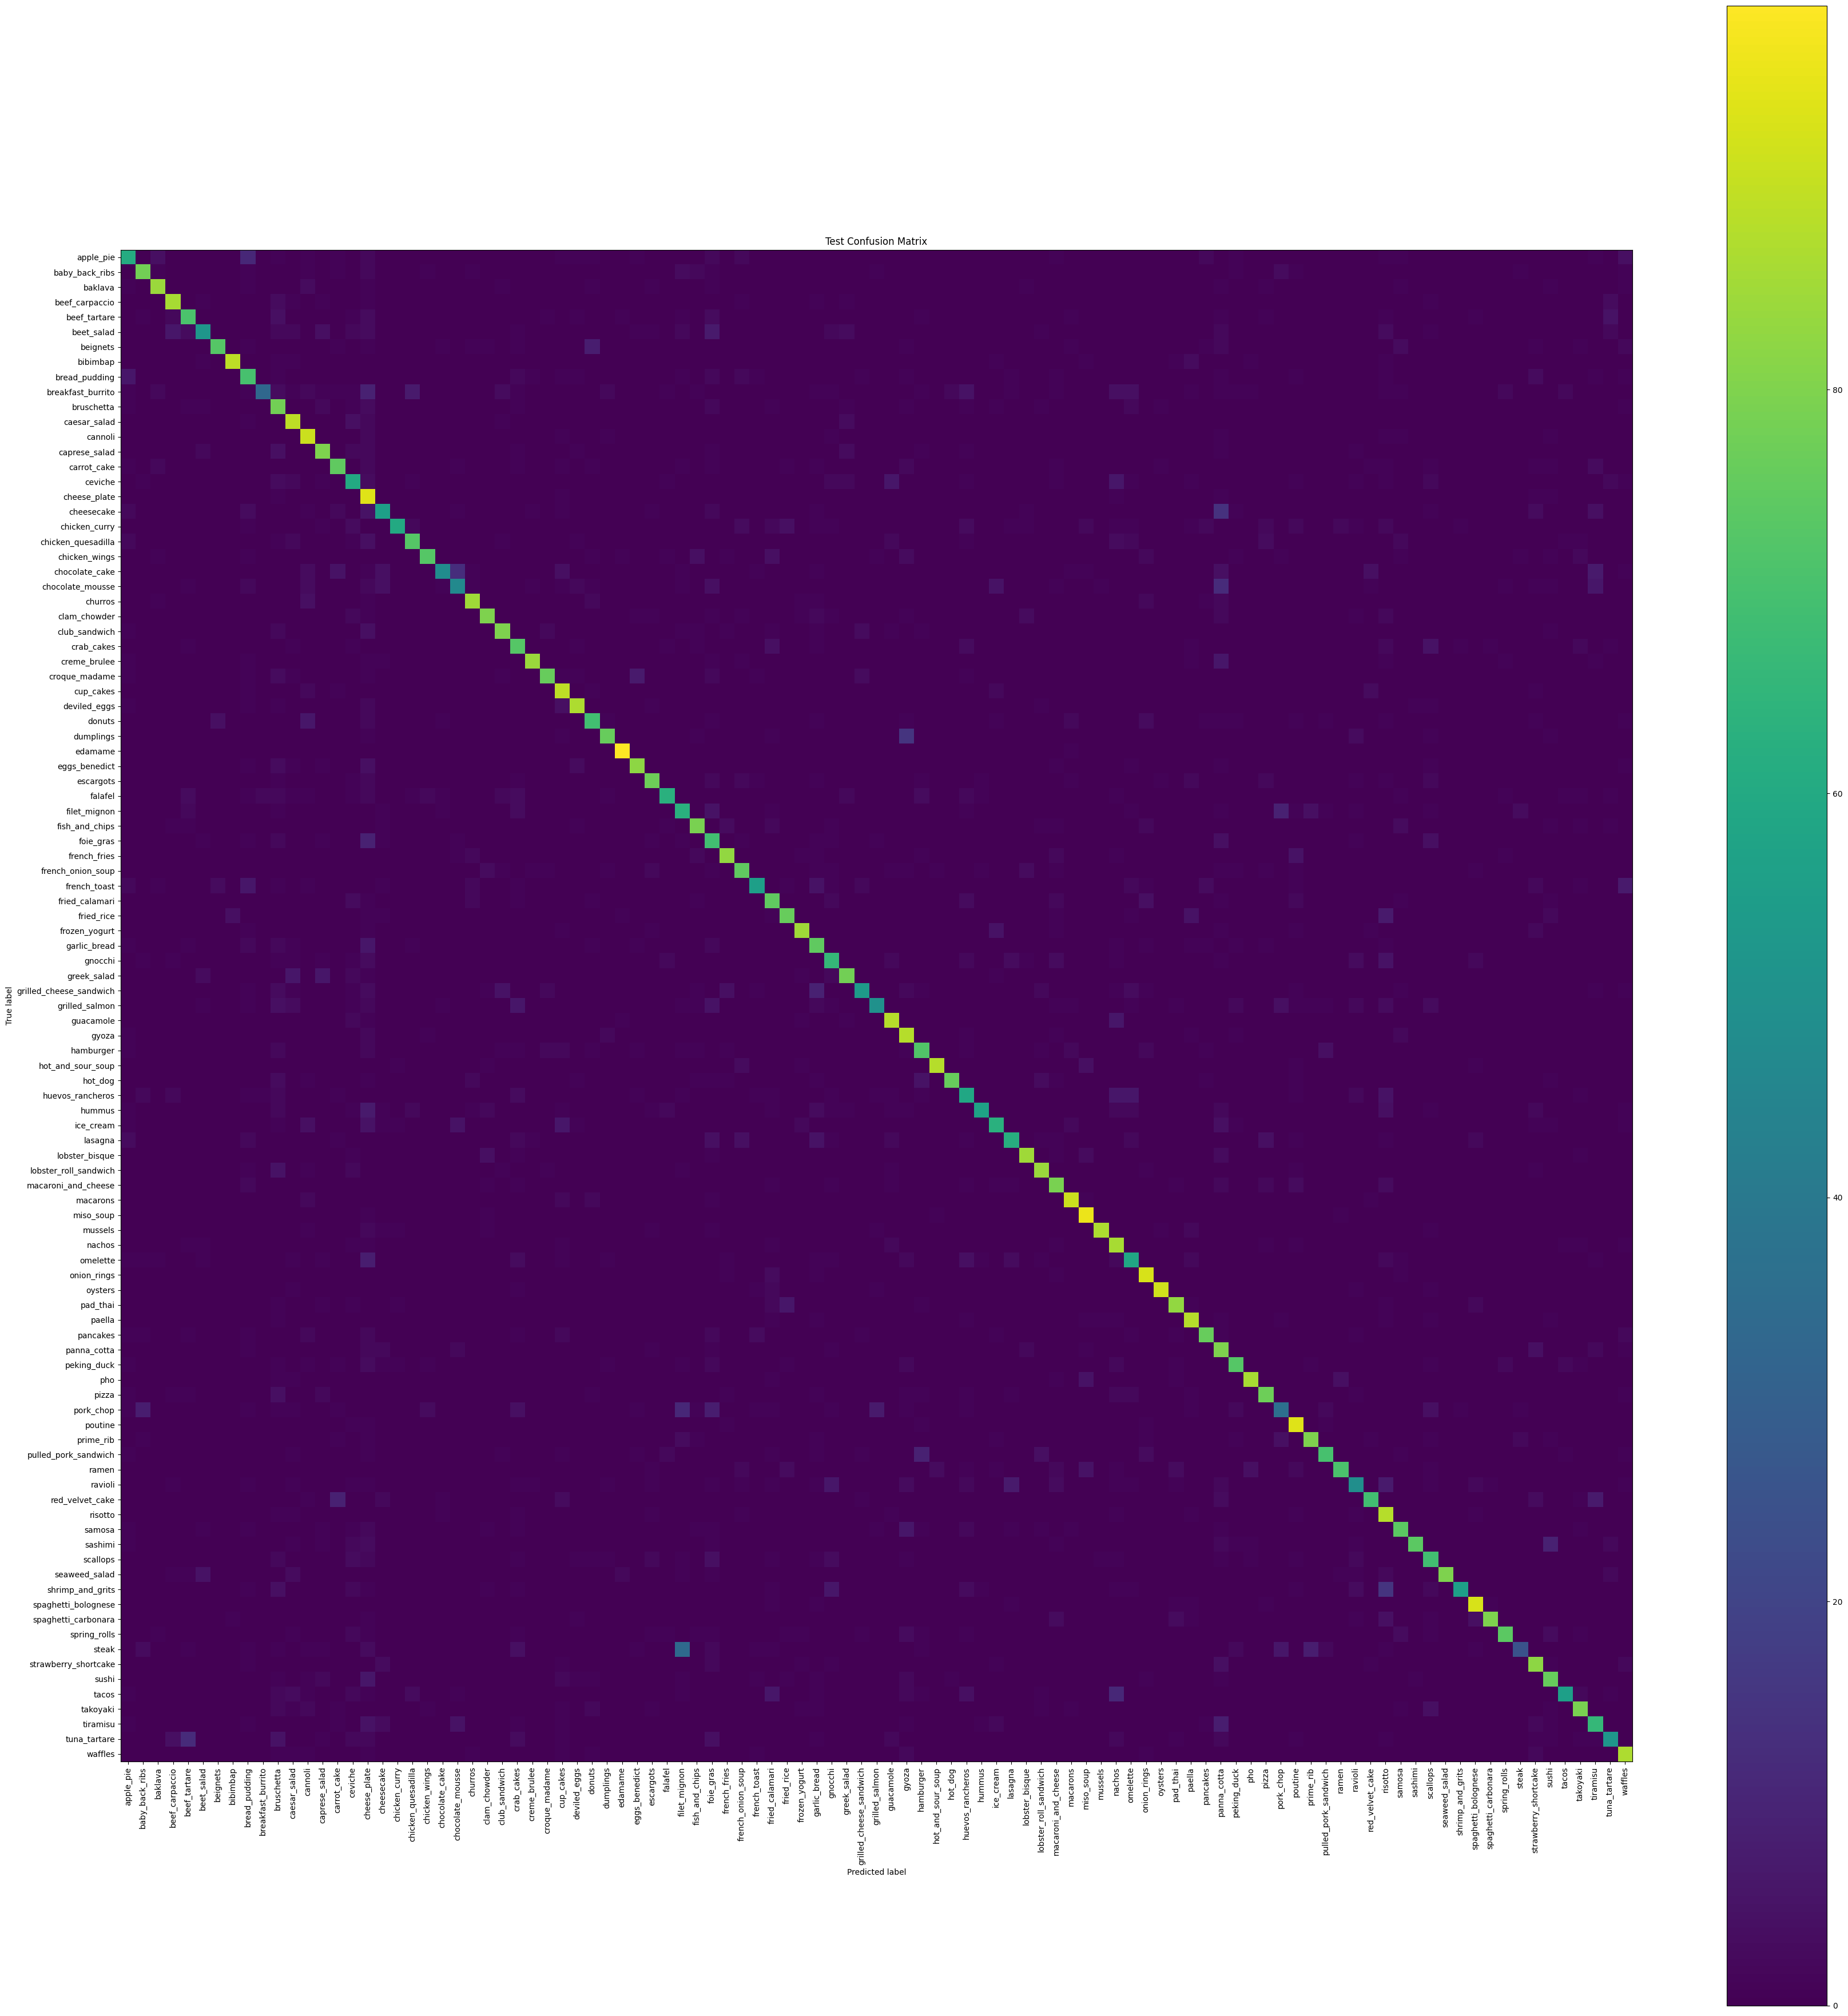

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import os

# Confusion matrices get huge if you have lots of classes.
# We'll plot it regardless, but also save a CSV for easier viewing.
cm = confusion_matrix(test_labels, test_preds, labels=list(range(num_classes)))

# Save matrix as CSV
cm_csv_path = os.path.join(OUTPUT_DIR, "confusion_matrix_test.csv")
np.savetxt(cm_csv_path, cm, delimiter=",", fmt="%d")
print("Saved confusion matrix CSV to:", cm_csv_path)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(max(8, num_classes * 0.35), max(6, num_classes * 0.35)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(include_values=False, xticks_rotation=90, ax=ax, colorbar=True)
ax.set_title("Test Confusion Matrix")

# Adjust layout and save figure
fig.tight_layout()
cm_png_path = os.path.join(OUTPUT_DIR, "confusion_matrix_test.png")
fig.savefig(cm_png_path, dpi=200)
print("Saved confusion matrix PNG to:", cm_png_path)

plt.show()


In [12]:
import os
print(os.listdir("food_model_out") if os.path.exists("food_model_out") else "No output directory yet")

['best_model.pt', 'confusion_matrix_test.csv', 'confusion_matrix_test.png', 'idx_to_class.json']


In [ ]:
import shutil
import os

# Clean up and re-create split directory for a fresh start (optional, but good for iterative development/testing)
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)
    print(f"Deleted {SPLIT_DIR}")
os.makedirs(SPLIT_DIR, exist_ok=True)
print(f"Created fresh {SPLIT_DIR}")